# Latin Square Rules — DiT Learning Analysis (Revised)

**Analysis order:**
1. n=6 rule complexity: RowOnly → LatinSquare → Sudoku **(scalar first)**
2. n=6 rule complexity: same three rules **(one-hot)**
3. One-hot encoding ablation (LatinSq n=6): plain / zeromean / zeroone
4. Model scale: DiT-mini vs DiT-B (n=6)
5. Grid size: n=5 vs n=6

Metrics per experiment:
- `eval/full_valid_ratio` — all row+col (+ block for sudoku) constraints satisfied
- `eval/row_valid_ratio` / `eval/col_valid_ratio` — individual constraint breakdown
- `eval/sample_mem_ratio` — fraction of generated samples in training set
- `train/loss` — DSM training loss


In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# ── Global style ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.labelsize':     11,
    'axes.titlesize':     12,
    'legend.fontsize':    9,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'figure.dpi':         120,
})

SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "../figures/latinsq_analysis"
SAVE     = True
os.makedirs(FIGDIR, exist_ok=True)


In [2]:
def load_tb(exp):
    tb_dir = os.path.join(SAVEROOT, exp, 'tensorboard')
    ea = EventAccumulator(tb_dir, size_guidance={'scalars': 0})
    ea.Reload()
    data = {}
    for tag in ea.Tags()['scalars']:
        evts = ea.Scalars(tag)
        data[tag] = (np.array([e.step  for e in evts]),
                     np.array([e.value for e in evts]))
    return data


# Pre-load all experiments
EXPS = {
    # n=6 scalar
    'RowOnly/scalar':          'DiT_mini_rowOnly_n6_N4096_scalar',
    'LatinSq/scalar':          'DiT_mini_latinSq_n6_N4096_scalar',
    'Sudoku/scalar':           'DiT_mini_sudoku6x6_N4096_scalar',
    # n=6 onehot
    'RowOnly/onehot':          'DiT_mini_rowOnly_n6_N4096_onehot_zeromean_autoSD',
    'LatinSq/onehot':          'DiT_mini_latinSq_n6_N4096_onehot',
    'Sudoku/onehot':           'DiT_mini_sudoku6x6_N4096_onehot_zeromean_autoSD',
    # onehot ablations (LatinSq n=6)
    'LatinSq/oh-plain':        'DiT_mini_latinSq_n6_N4096_onehot',
    'LatinSq/oh-zeromean':     'DiT_mini_latinSq_n6_N4096_onehot_zeromean_autoSD',
    'LatinSq/oh-zeroone':      'DiT_mini_latinSq_n6_N4096_onehot_zeroone_autoSD',
    # model scale n=6
    'mini/LatinSq-scalar':     'DiT_mini_latinSq_n6_N4096_scalar',
    'B/LatinSq-scalar':        'DiT_B_latinSq_n6_N4096_scalar',
    'mini/LatinSq-onehot':     'DiT_mini_latinSq_n6_N4096_onehot',
    'B/LatinSq-onehot':        'DiT_B_latinSq_n6_N4096_onehot',
    # n=5 vs n=6
    'mini/n5-scalar':          'DiT_mini_latinSq_n5_N4096_scalar',
    'mini/n6-scalar':          'DiT_mini_latinSq_n6_N4096_scalar',
    'mini/n5-onehot':          'DiT_mini_latinSq_n5_N4096_onehot',
    'mini/n6-onehot':          'DiT_mini_latinSq_n6_N4096_onehot',
    'B/n5-scalar':             'DiT_B_latinSq_n5_N4096_scalar',
    'B/n6-scalar':             'DiT_B_latinSq_n6_N4096_scalar',
    'B/n5-onehot':             'DiT_B_latinSq_n5_N4096_onehot',
    'B/n6-onehot':             'DiT_B_latinSq_n6_N4096_onehot',
}

tb = {}
for key, exp in EXPS.items():
    try:
        tb[key] = load_tb(exp)
        last = tb[key]['train/loss'][0][-1]
        fv   = tb[key].get('eval/full_valid_ratio', ([], [np.nan]))[1][-1]
        print(f"{key:<28} last_step={last:>8}  fv={fv:.3f}")
    except Exception as e:
        print(f"{key:<28} FAILED: {e}")
        tb[key] = {}


RowOnly/scalar               last_step= 1000000  fv=0.874


LatinSq/scalar               last_step= 1000000  fv=0.600


Sudoku/scalar                last_step= 1000000  fv=0.943


RowOnly/onehot               last_step= 1000000  fv=0.842


LatinSq/onehot               last_step= 1000000  fv=0.762


...

mini/n6-onehot               last_step= 1000000  fv=0.762


B/n5-scalar                  last_step= 1000000  fv=0.995


B/n6-scalar                  last_step= 1000000  fv=0.962


B/n5-onehot                  last_step= 1000000  fv=0.942


B/n6-onehot                  last_step= 1000000  fv=0.754


In [3]:
def savefig(fig, name):
    if SAVE:
        p = os.path.join(FIGDIR, name)
        fig.savefig(p, dpi=150, bbox_inches='tight')
        print(f"Saved {p}")


METRICS_FULL = [
    ('train/loss',            'Train loss',         True,  None),
    ('eval/full_valid_ratio', 'Full valid',         False, (0, 1.02)),
    ('eval/row_valid_ratio',  'Row valid',          False, (0, 1.02)),
    ('eval/col_valid_ratio',  'Col valid',          False, (0, 1.02)),
    ('eval/sample_mem_ratio', 'Memorization',       False, (0, 1.02)),
]


def multi_curve(ax, keys_colors_labels, tag, log_y=False, ylim=None, smooth=0):
    for key, color, label in keys_colors_labels:
        d = tb.get(key, {})
        if tag not in d: continue
        steps, vals = d[tag]
        if smooth > 1:
            kernel = np.ones(smooth) / smooth
            vals = np.convolve(vals, kernel, mode='same')
        ax.plot(steps, vals, color=color, lw=1.8, label=label, alpha=0.9)
    ax.set_xscale('log')
    if log_y: ax.set_yscale('log')
    if ylim:  ax.set_ylim(*ylim)
    ax.set_xlabel('Training step')
    ax.legend()
    ax.grid(axis='y', ls='--', alpha=0.35)


def comparison_figure(groups, metrics, title, fname, ncols=None, smooth=0):
    """
    groups: list of (group_label, [(tb_key, color, line_label), ...])
    metrics: list of (tag, ylabel, log_y, ylim)
    """
    nrows = len(groups)
    ncols = ncols or len(metrics)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.8*nrows),
                             sharex=True, squeeze=False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for r, (grp_label, kvlist) in enumerate(groups):
        for c, (tag, ylabel, log_y, ylim) in enumerate(metrics):
            ax = axes[r, c]
            multi_curve(ax, kvlist, tag, log_y=log_y, ylim=ylim, smooth=smooth)
            ax.set_ylabel(grp_label + '\n' + ylabel if c == 0 else ylabel)
            if r == 0: ax.set_title(ylabel)

    plt.tight_layout()
    savefig(fig, fname)
    return fig


## 1. n=6 Rule Complexity — Scalar Encoding

RowOnly (row permutation only) → LatinSquare (row+col) → Sudoku 6×6 (row+col+block).

Saved ../figures/latinsq_analysis/n6_scalar_rule_comparison.png


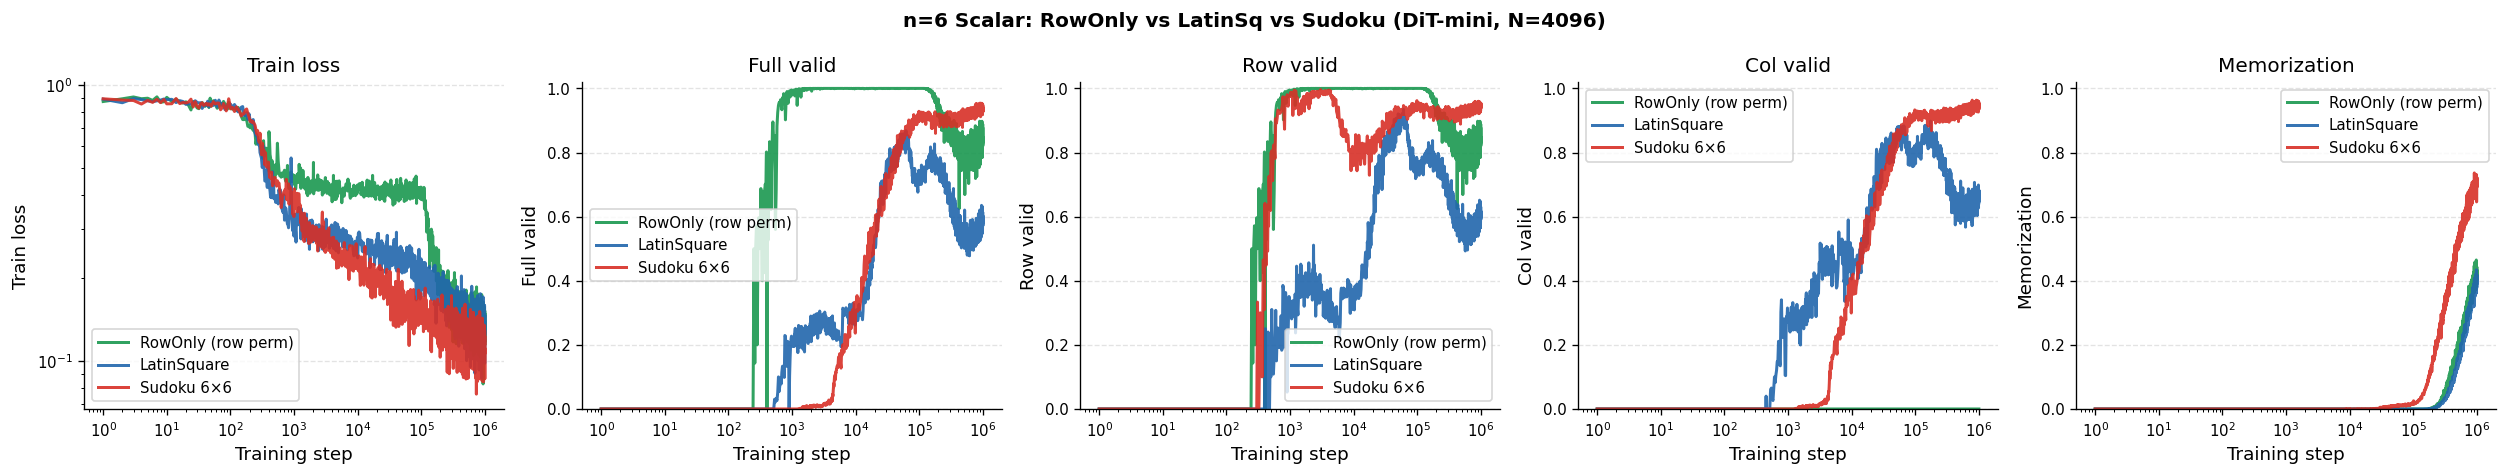

In [4]:
C_ROW    = '#1a9850'   # green
C_LATIN  = '#2166ac'   # blue
C_SUDOKU = '#d73027'   # red

scalar_kvs = [
    ('RowOnly/scalar',  C_ROW,    'RowOnly (row perm)'),
    ('LatinSq/scalar',  C_LATIN,  'LatinSquare'),
    ('Sudoku/scalar',   C_SUDOKU, 'Sudoku 6×6'),
]

metrics_n6 = [
    ('train/loss',            'Train loss',   True,  None),
    ('eval/full_valid_ratio', 'Full valid',   False, (0, 1.02)),
    ('eval/row_valid_ratio',  'Row valid',    False, (0, 1.02)),
    ('eval/col_valid_ratio',  'Col valid',    False, (0, 1.02)),
    ('eval/sample_mem_ratio', 'Memorization', False, (0, 1.02)),
]

fig, axes = plt.subplots(1, len(metrics_n6), figsize=(4.2*len(metrics_n6), 4))
fig.suptitle("n=6 Scalar: RowOnly vs LatinSq vs Sudoku (DiT-mini, N=4096)", 
             fontsize=12, fontweight='bold')

for ax, (tag, ylabel, log_y, ylim) in zip(axes, metrics_n6):
    multi_curve(ax, scalar_kvs, tag, log_y=log_y, ylim=ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
savefig(fig, 'n6_scalar_rule_comparison.png')
plt.show()


Saved ../figures/latinsq_analysis/n6_scalar_rowcol_breakdown.png


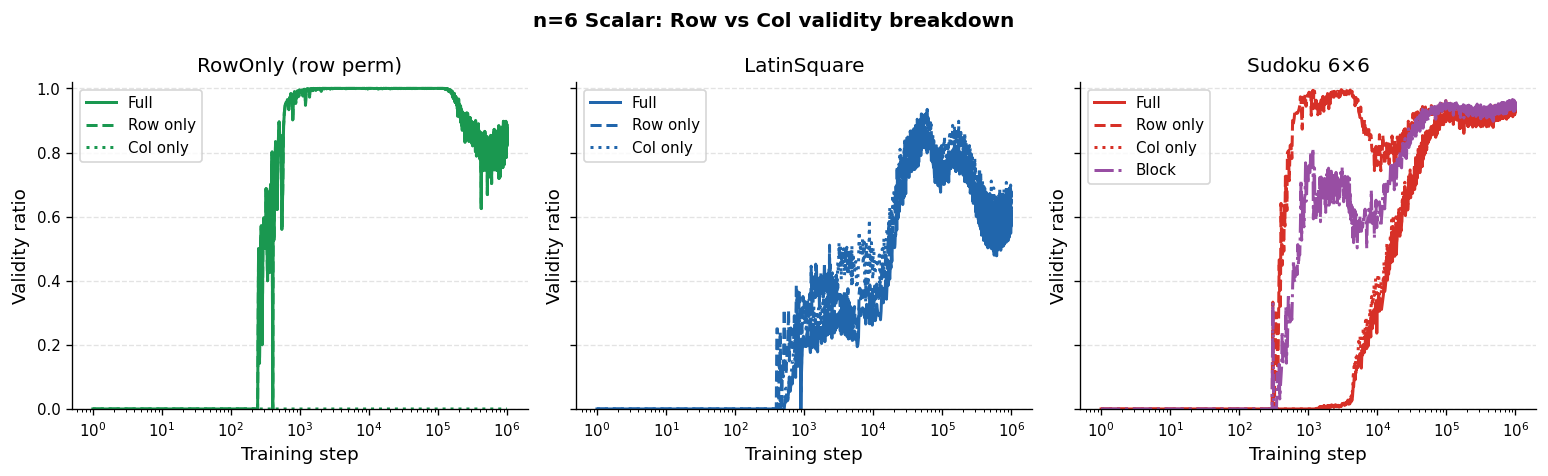

In [5]:
# Row vs Col valid ratio — side-by-side per rule
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle("n=6 Scalar: Row vs Col validity breakdown", fontsize=12, fontweight='bold')

for ax, (key, color, label) in zip(axes, scalar_kvs):
    d = tb.get(key, {})
    for tag, ls, lbl in [
        ('eval/full_valid_ratio', '-',  'Full'),
        ('eval/row_valid_ratio',  '--', 'Row only'),
        ('eval/col_valid_ratio',  ':',  'Col only'),
    ]:
        if tag in d:
            steps, vals = d[tag]
            ax.plot(steps, vals, color=color, ls=ls, lw=1.8, label=lbl)
    if 'eval/block_valid_ratio' in d:
        steps, vals = d['eval/block_valid_ratio']
        ax.plot(steps, vals, color='#984ea3', ls='-.', lw=1.8, label='Block')
    ax.set_xscale('log')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Validity ratio')
    ax.set_title(label)
    ax.set_ylim(0, 1.02)
    ax.legend()
    ax.grid(axis='y', ls='--', alpha=0.35)

plt.tight_layout()
savefig(fig, 'n6_scalar_rowcol_breakdown.png')
plt.show()


## 2. n=6 Rule Complexity — One-hot Encoding

Saved ../figures/latinsq_analysis/n6_onehot_rule_comparison.png


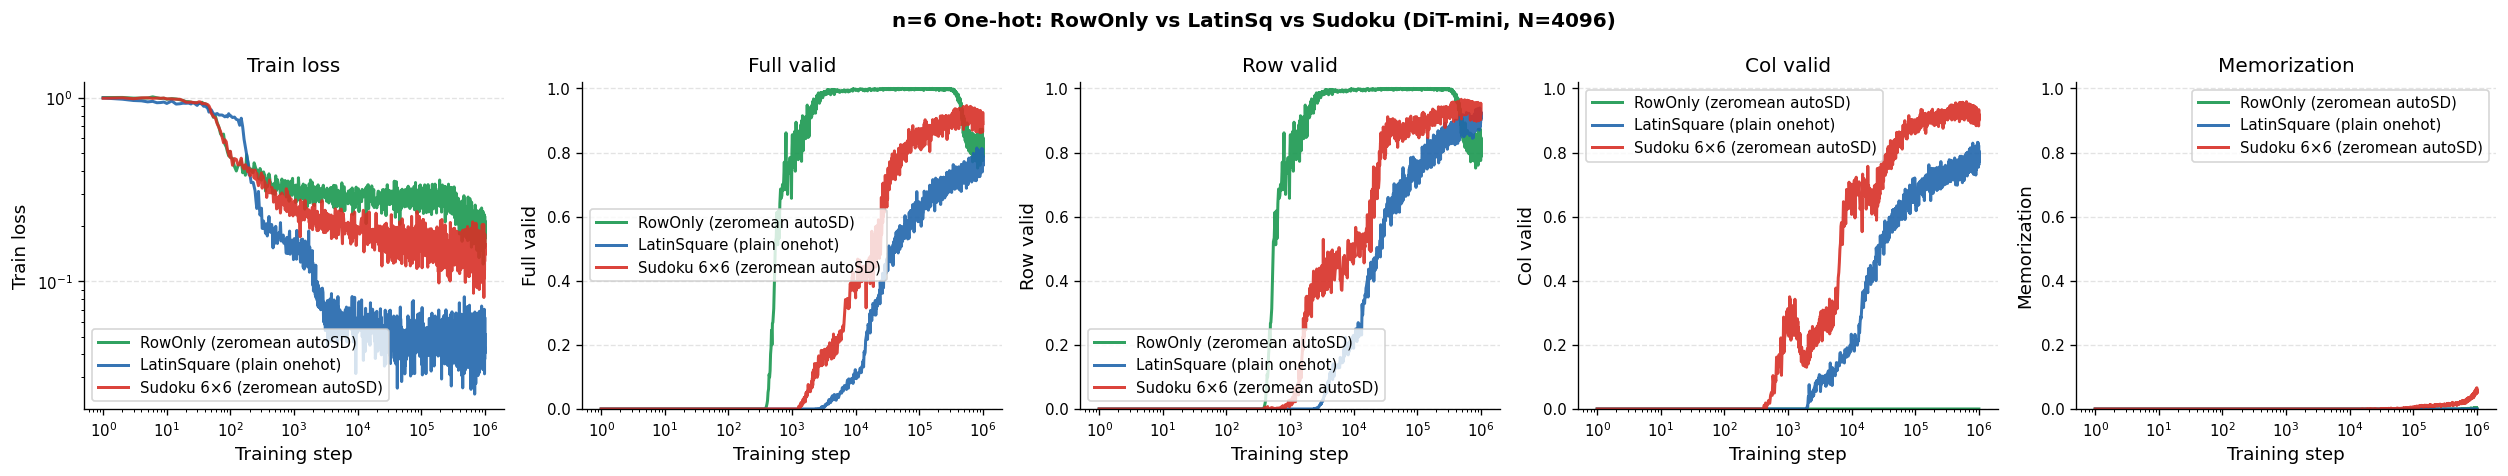

In [6]:
onehot_kvs = [
    ('RowOnly/onehot',  C_ROW,    'RowOnly (zeromean autoSD)'),
    ('LatinSq/onehot',  C_LATIN,  'LatinSquare (plain onehot)'),
    ('Sudoku/onehot',   C_SUDOKU, 'Sudoku 6×6 (zeromean autoSD)'),
]

fig, axes = plt.subplots(1, len(metrics_n6), figsize=(4.2*len(metrics_n6), 4))
fig.suptitle("n=6 One-hot: RowOnly vs LatinSq vs Sudoku (DiT-mini, N=4096)",
             fontsize=12, fontweight='bold')

for ax, (tag, ylabel, log_y, ylim) in zip(axes, metrics_n6):
    multi_curve(ax, onehot_kvs, tag, log_y=log_y, ylim=ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
savefig(fig, 'n6_onehot_rule_comparison.png')
plt.show()


Saved ../figures/latinsq_analysis/n6_scalar_vs_onehot_all_rules.png


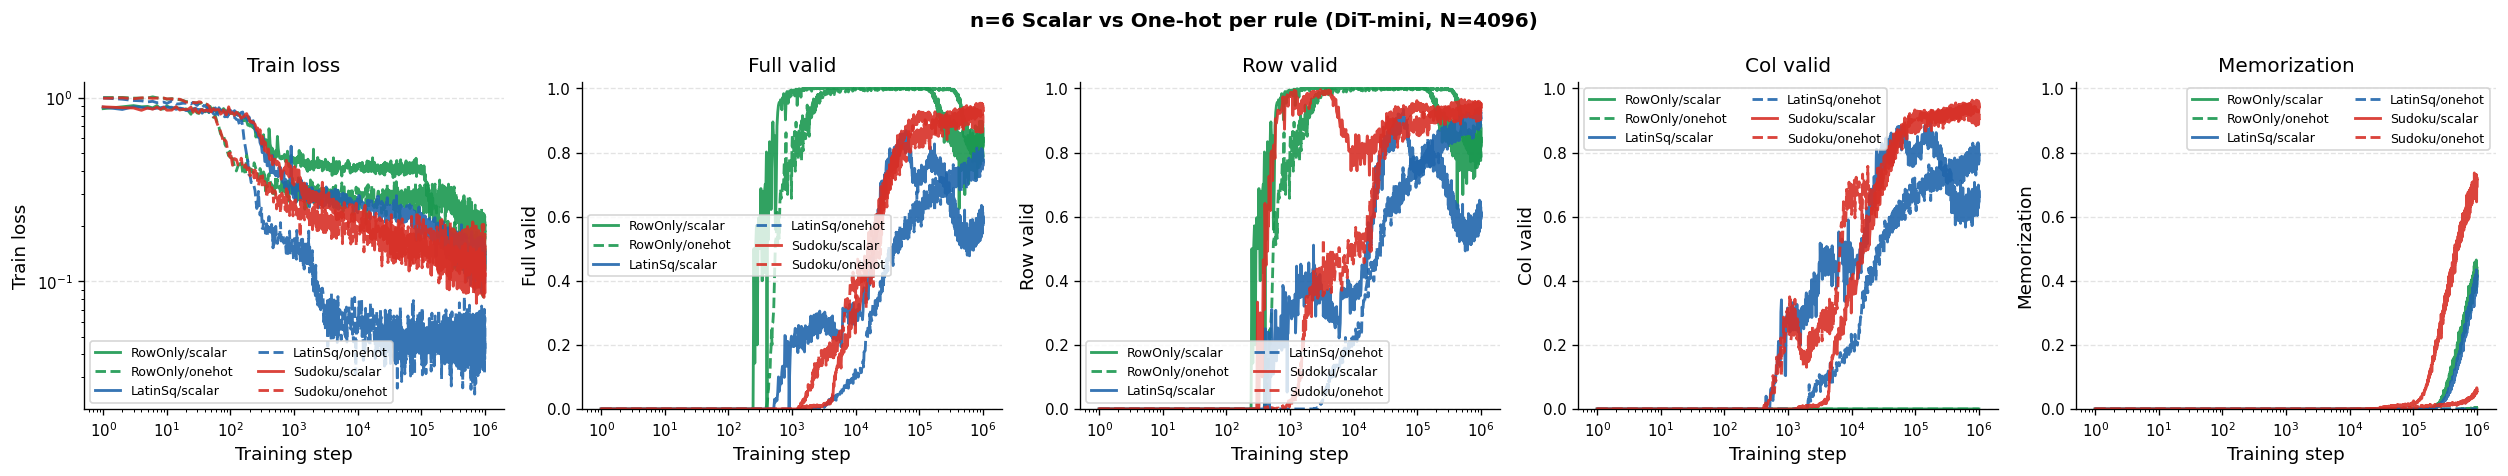

In [7]:
# For each rule: scalar (solid) vs onehot (dashed) in same color
fig, axes = plt.subplots(1, len(metrics_n6), figsize=(4.2*len(metrics_n6), 4))
fig.suptitle("n=6 Scalar vs One-hot per rule (DiT-mini, N=4096)",
             fontsize=12, fontweight='bold')

enc_pairs = [
    ('RowOnly/scalar',  'RowOnly/onehot',  C_ROW,    'RowOnly'),
    ('LatinSq/scalar',  'LatinSq/onehot',  C_LATIN,  'LatinSq'),
    ('Sudoku/scalar',   'Sudoku/onehot',   C_SUDOKU, 'Sudoku'),
]

for ax, (tag, ylabel, log_y, ylim) in zip(axes, metrics_n6):
    for sc_key, oh_key, color, label in enc_pairs:
        for key, ls, suffix in [(sc_key, '-', 'scalar'), (oh_key, '--', 'onehot')]:
            d = tb.get(key, {})
            if tag not in d: continue
            steps, vals = d[tag]
            ax.plot(steps, vals, color=color, ls=ls, lw=1.7,
                    label=f'{label}/{suffix}', alpha=0.9)
    ax.set_xscale('log')
    if log_y: ax.set_yscale('log')
    if ylim:  ax.set_ylim(*ylim)
    ax.set_xlabel('Training step')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=7.5, ncol=2)
    ax.grid(axis='y', ls='--', alpha=0.35)

plt.tight_layout()
savefig(fig, 'n6_scalar_vs_onehot_all_rules.png')
plt.show()


## 3. One-hot Encoding Ablation — LatinSq n=6

Compare plain one-hot, zero-mean autoSD, and zero-one autoSD against scalar baseline.

Saved ../figures/latinsq_analysis/n6_latinsq_onehot_ablation.png


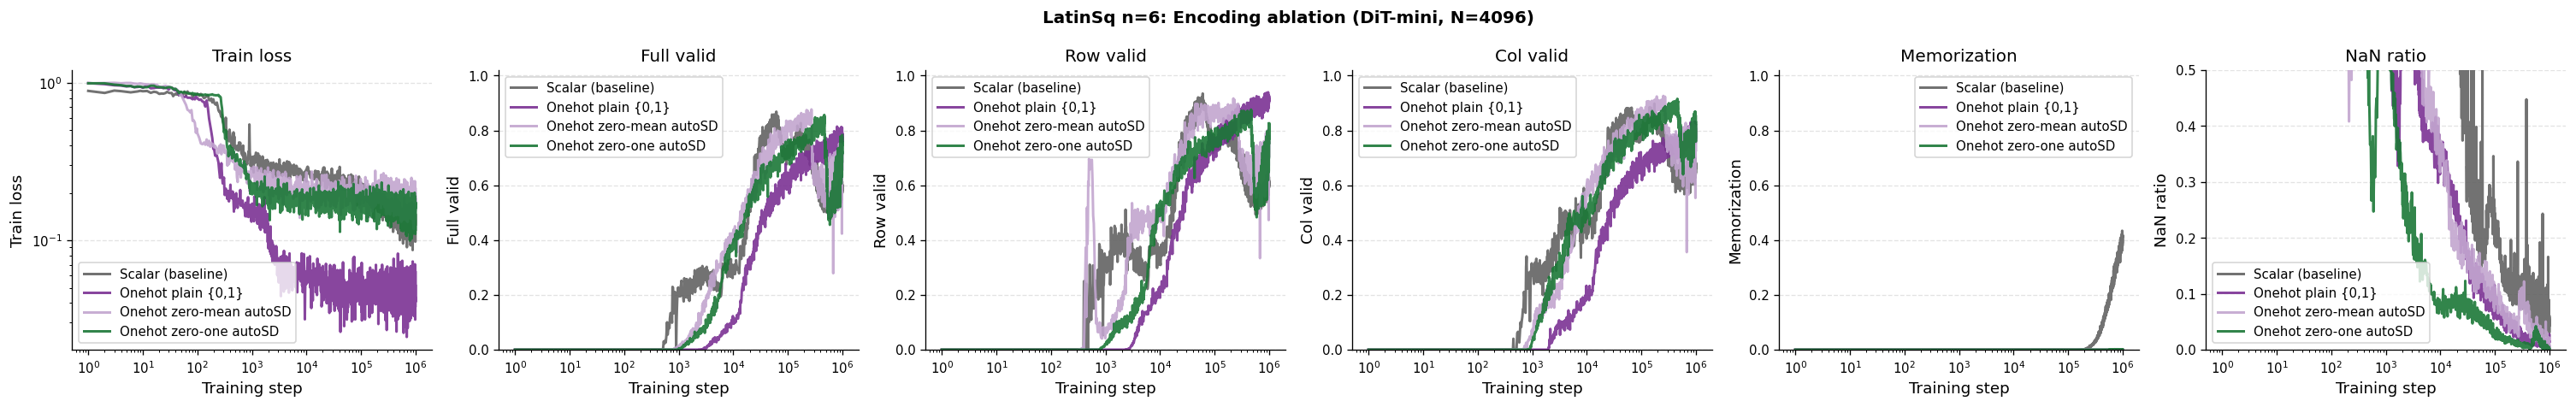

In [8]:
C_SC   = '#636363'   # gray for scalar
C_OH1  = '#7b3294'   # purple
C_OH2  = '#c2a5cf'
C_OH3  = '#1b7837'

ablation_kvs = [
    ('LatinSq/scalar',      C_SC,  'Scalar (baseline)'),
    ('LatinSq/oh-plain',    C_OH1, 'Onehot plain {0,1}'),
    ('LatinSq/oh-zeromean', C_OH2, 'Onehot zero-mean autoSD'),
    ('LatinSq/oh-zeroone',  C_OH3, 'Onehot zero-one autoSD'),
]

metrics_abl = [
    ('train/loss',            'Train loss',   True,  None),
    ('eval/full_valid_ratio', 'Full valid',   False, (0, 1.02)),
    ('eval/row_valid_ratio',  'Row valid',    False, (0, 1.02)),
    ('eval/col_valid_ratio',  'Col valid',    False, (0, 1.02)),
    ('eval/sample_mem_ratio', 'Memorization', False, (0, 1.02)),
    ('eval/nan_ratio_strict', 'NaN ratio',    False, (0, 0.5)),
]

fig, axes = plt.subplots(1, len(metrics_abl), figsize=(4.2*len(metrics_abl), 4))
fig.suptitle("LatinSq n=6: Encoding ablation (DiT-mini, N=4096)",
             fontsize=12, fontweight='bold')

for ax, (tag, ylabel, log_y, ylim) in zip(axes, metrics_abl):
    multi_curve(ax, ablation_kvs, tag, log_y=log_y, ylim=ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
savefig(fig, 'n6_latinsq_onehot_ablation.png')
plt.show()


Saved ../figures/latinsq_analysis/n6_latinsq_onehot_ablation_bar.png


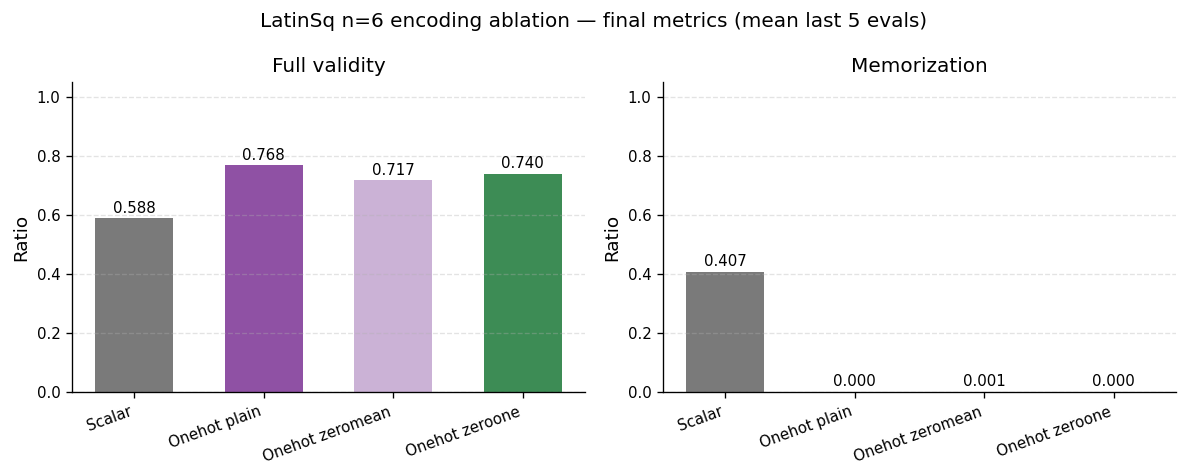

In [9]:
def final_mean(key, tag, n=5):
    d = tb.get(key, {})
    if tag not in d: return np.nan
    return float(d[tag][1][-n:].mean())

abl_labels = ['Scalar', 'Onehot plain', 'Onehot zeromean', 'Onehot zeroone']
abl_keys   = ['LatinSq/scalar','LatinSq/oh-plain','LatinSq/oh-zeromean','LatinSq/oh-zeroone']
abl_colors = [C_SC, C_OH1, C_OH2, C_OH3]

fv  = [final_mean(k, 'eval/full_valid_ratio') for k in abl_keys]
mem = [final_mean(k, 'eval/sample_mem_ratio')  for k in abl_keys]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("LatinSq n=6 encoding ablation — final metrics (mean last 5 evals)", fontsize=12)

x = np.arange(len(abl_labels))
for ax, vals, title in [(axes[0], fv, 'Full validity'), (axes[1], mem, 'Memorization')]:
    bars = ax.bar(x, vals, color=abl_colors, width=0.6, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(abl_labels, rotation=20, ha='right')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Ratio'); ax.set_title(title)
    ax.grid(axis='y', ls='--', alpha=0.35)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
savefig(fig, 'n6_latinsq_onehot_ablation_bar.png')
plt.show()


## 4. Model Scale Comparison — DiT-mini vs DiT-B (n=6 LatinSq)

Saved ../figures/latinsq_analysis/n6_latinsq_model_scale.png


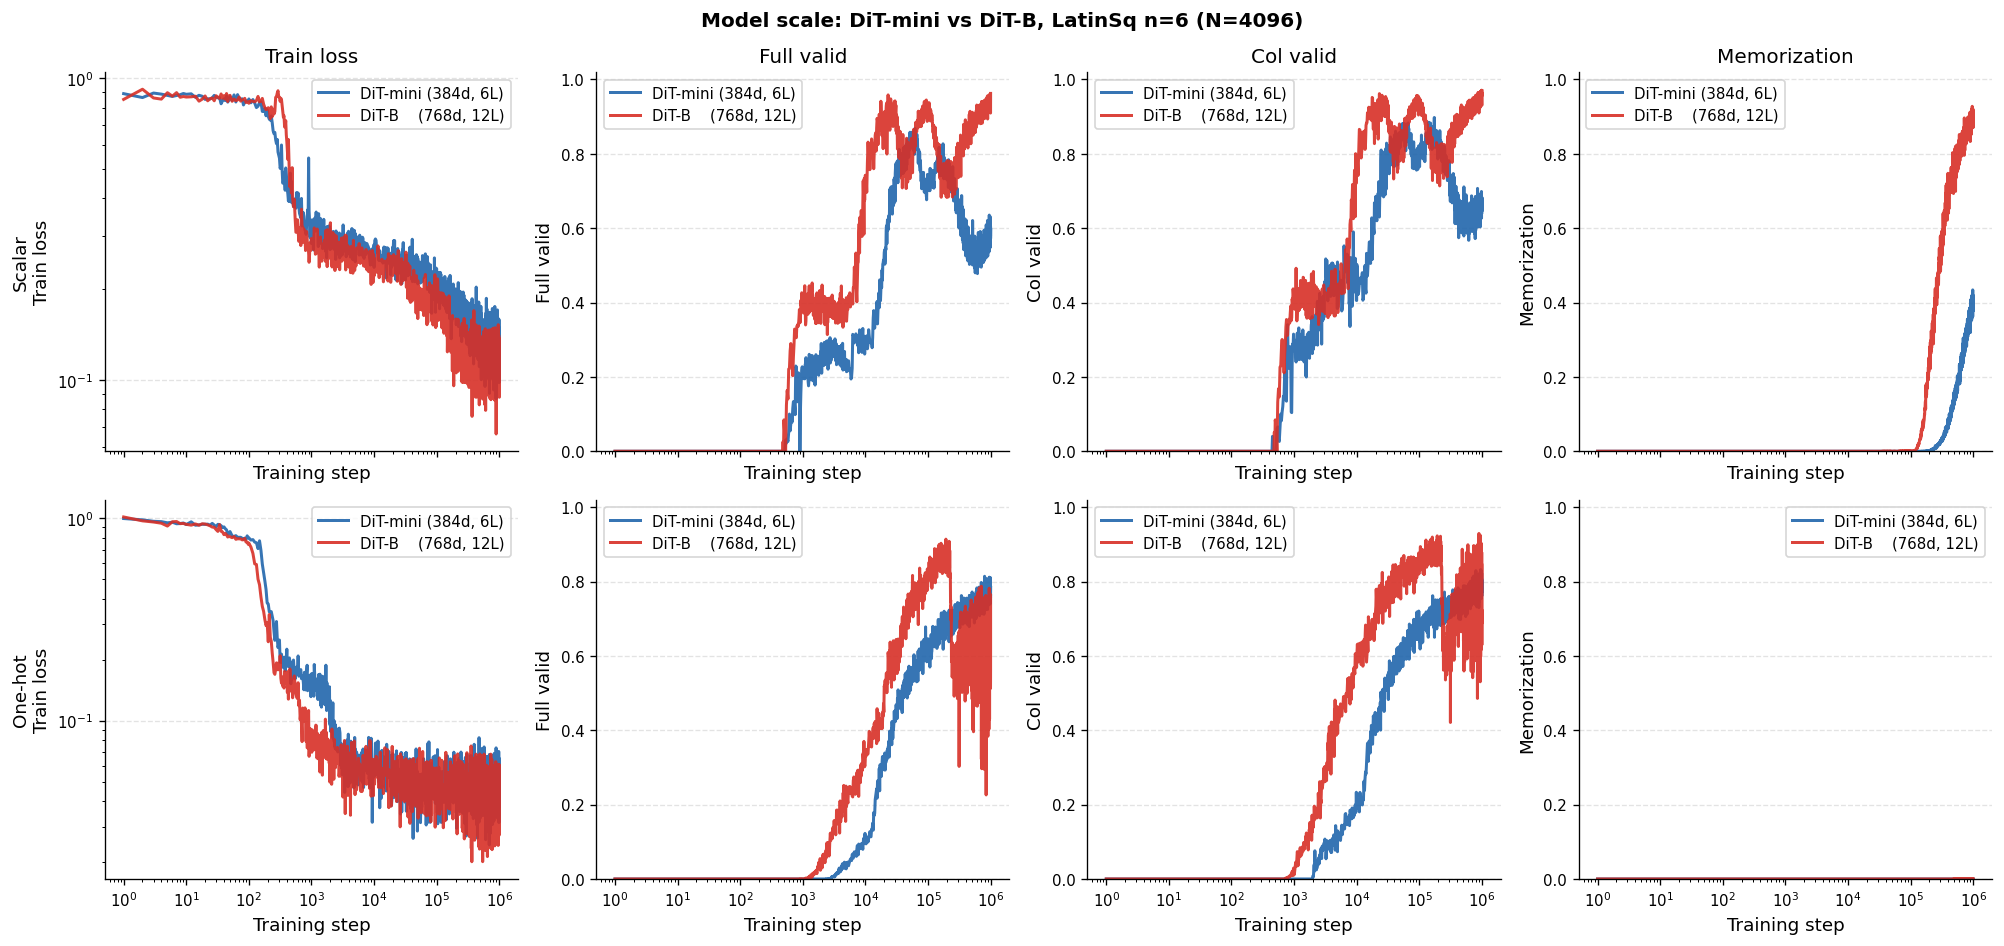

In [10]:
C_MINI = '#2166ac'
C_B    = '#d73027'

scale_metrics = [
    ('train/loss',            'Train loss',   True,  None),
    ('eval/full_valid_ratio', 'Full valid',   False, (0, 1.02)),
    ('eval/col_valid_ratio',  'Col valid',    False, (0, 1.02)),
    ('eval/sample_mem_ratio', 'Memorization', False, (0, 1.02)),
]

fig, axes = plt.subplots(2, len(scale_metrics), figsize=(4.2*len(scale_metrics), 8),
                          sharex=True)
fig.suptitle("Model scale: DiT-mini vs DiT-B, LatinSq n=6 (N=4096)", 
             fontsize=12, fontweight='bold')

for row, (enc_label, mini_key, B_key) in enumerate([
    ('Scalar',  'mini/LatinSq-scalar', 'B/LatinSq-scalar'),
    ('One-hot', 'mini/LatinSq-onehot', 'B/LatinSq-onehot'),
]):
    kvs = [
        (mini_key, C_MINI, 'DiT-mini (384d, 6L)'),
        (B_key,    C_B,    'DiT-B    (768d, 12L)'),
    ]
    for col, (tag, ylabel, log_y, ylim) in enumerate(scale_metrics):
        ax = axes[row, col]
        multi_curve(ax, kvs, tag, log_y=log_y, ylim=ylim)
        ax.set_ylabel(enc_label + '\n' + ylabel if col == 0 else ylabel)
        if row == 0: ax.set_title(ylabel)

plt.tight_layout()
savefig(fig, 'n6_latinsq_model_scale.png')
plt.show()


## 5. Grid Size Comparison — n=5 vs n=6 (LatinSq)

Saved ../figures/latinsq_analysis/latinsq_n5_vs_n6.png


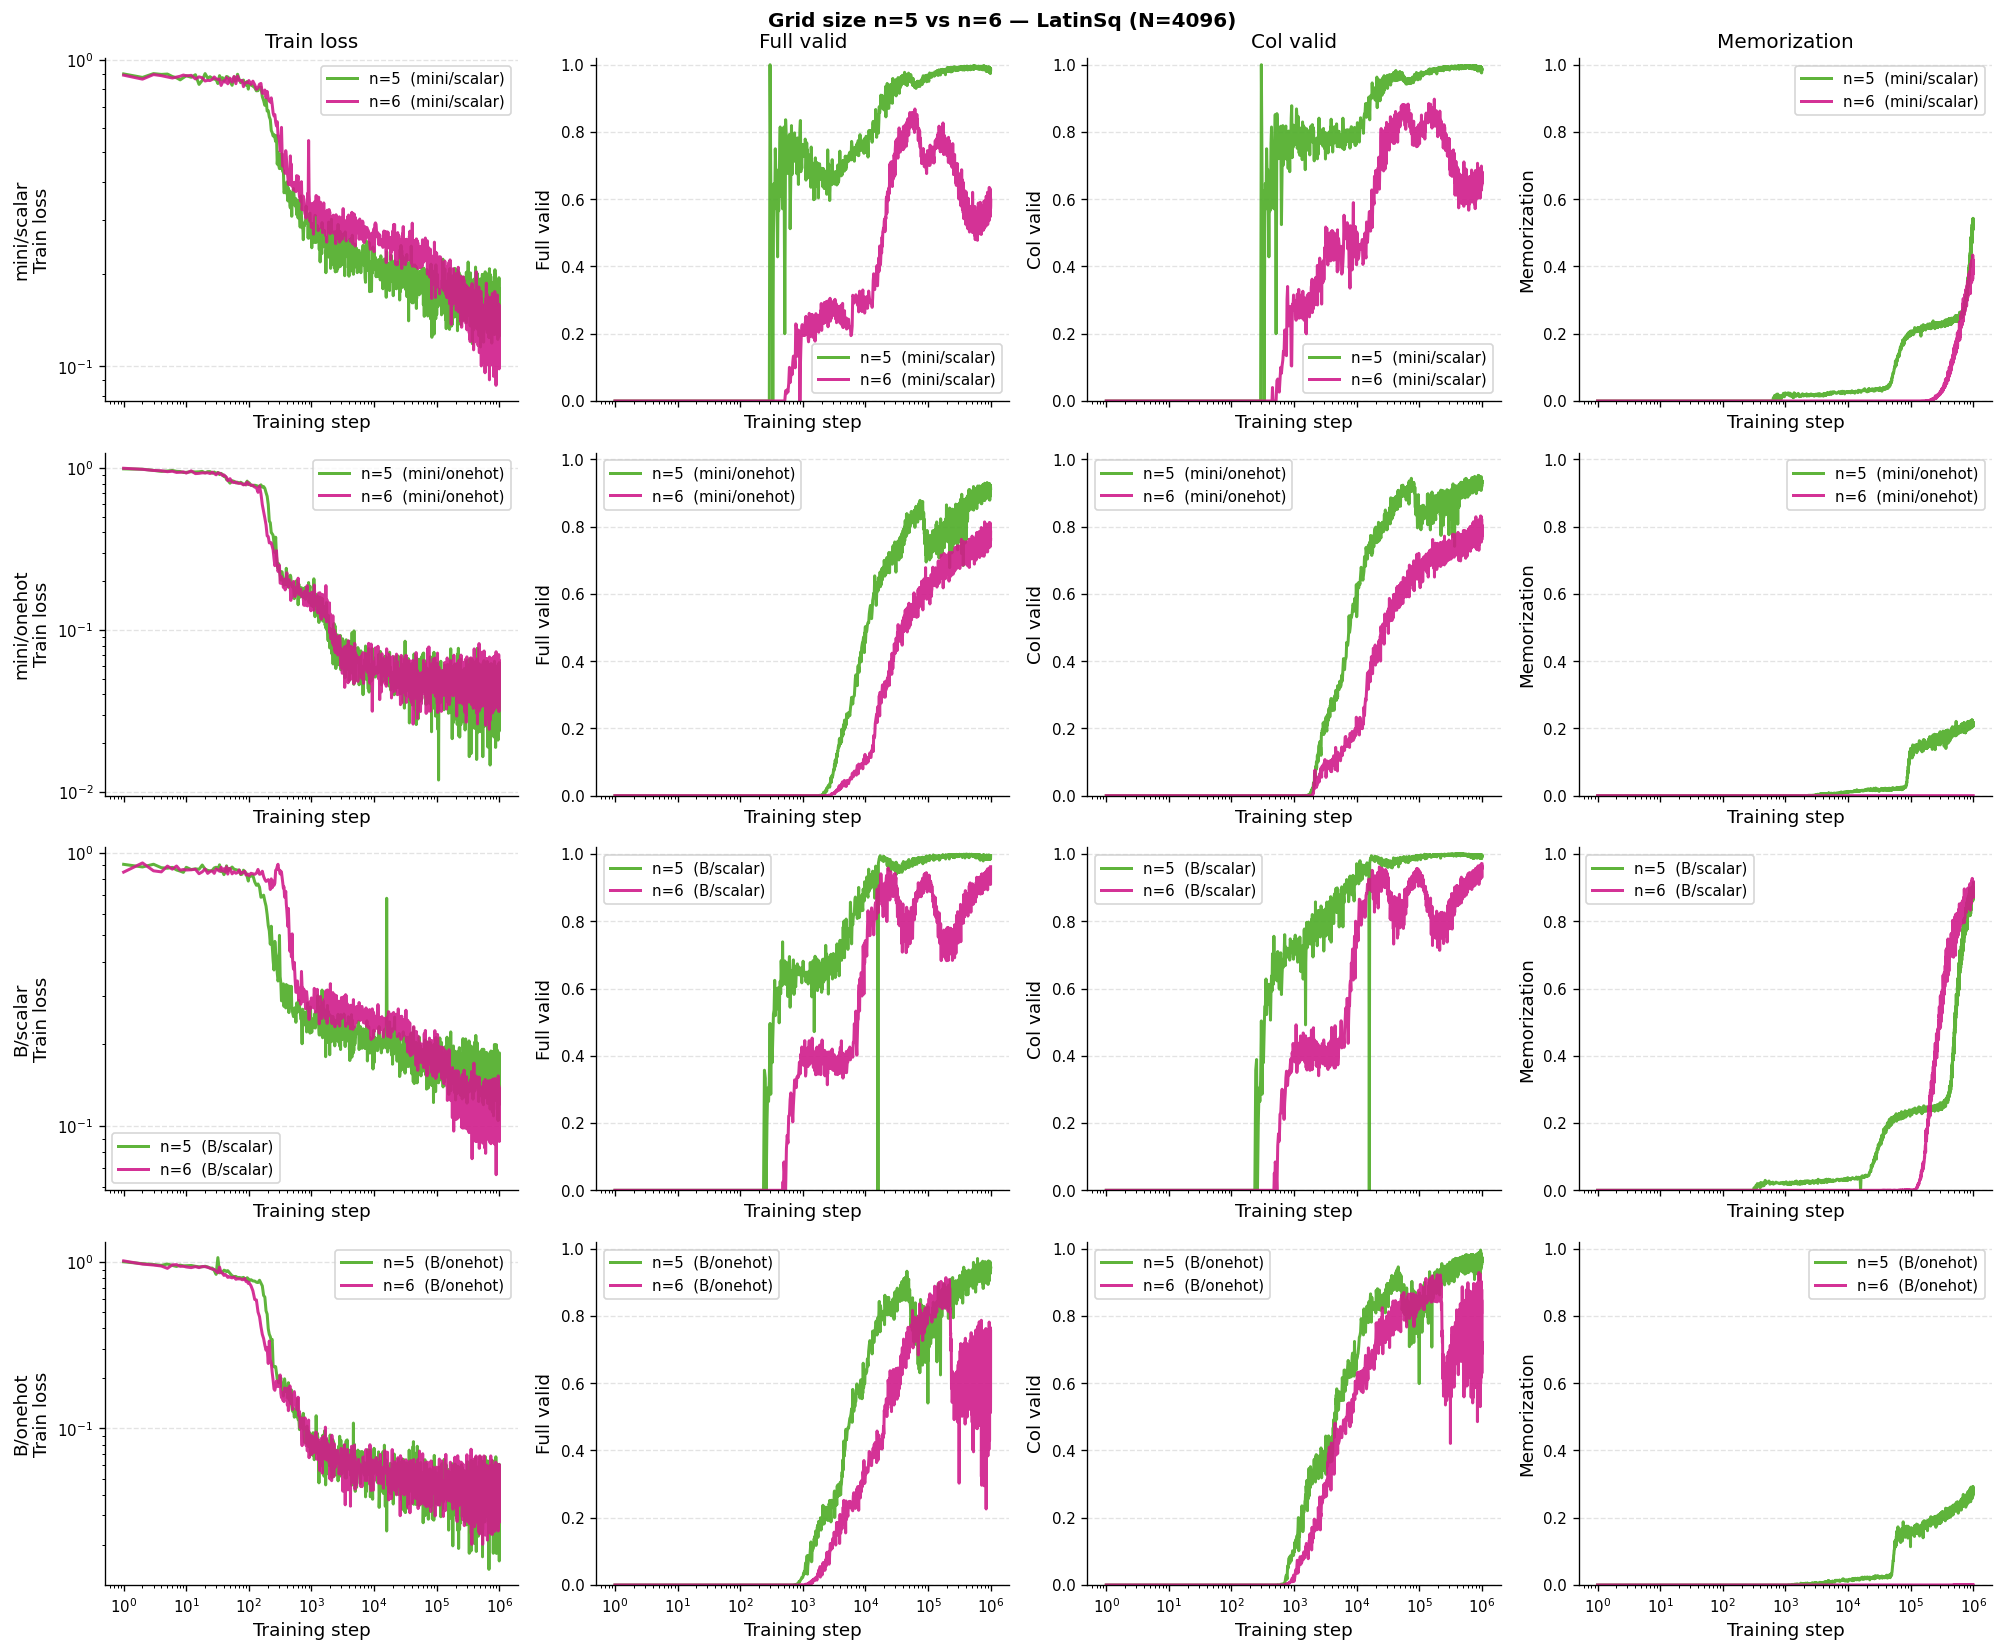

In [11]:
C_N5 = '#4dac26'
C_N6 = '#d01c8b'

size_metrics = [
    ('train/loss',            'Train loss',   True,  None),
    ('eval/full_valid_ratio', 'Full valid',   False, (0, 1.02)),
    ('eval/col_valid_ratio',  'Col valid',    False, (0, 1.02)),
    ('eval/sample_mem_ratio', 'Memorization', False, (0, 1.02)),
]

fig, axes = plt.subplots(4, len(size_metrics), figsize=(4.2*len(size_metrics), 14),
                          sharex=True)
fig.suptitle("Grid size n=5 vs n=6 — LatinSq (N=4096)", fontsize=12, fontweight='bold')

combos = [
    ('mini/scalar', 'mini/n5-scalar', 'mini/n6-scalar'),
    ('mini/onehot', 'mini/n5-onehot', 'mini/n6-onehot'),
    ('B/scalar',    'B/n5-scalar',    'B/n6-scalar'),
    ('B/onehot',    'B/n5-onehot',    'B/n6-onehot'),
]

for row, (row_label, n5_key, n6_key) in enumerate(combos):
    kvs = [
        (n5_key, C_N5, f'n=5  ({row_label})'),
        (n6_key, C_N6, f'n=6  ({row_label})'),
    ]
    for col, (tag, ylabel, log_y, ylim) in enumerate(size_metrics):
        ax = axes[row, col]
        multi_curve(ax, kvs, tag, log_y=log_y, ylim=ylim)
        ax.set_ylabel(row_label + '\n' + ylabel if col == 0 else ylabel)
        if row == 0: ax.set_title(ylabel)

plt.tight_layout()
savefig(fig, 'latinsq_n5_vs_n6.png')
plt.show()


## 6. Final Metrics Summary — All Experiments

Saved ../figures/latinsq_analysis/summary_all_experiments.png


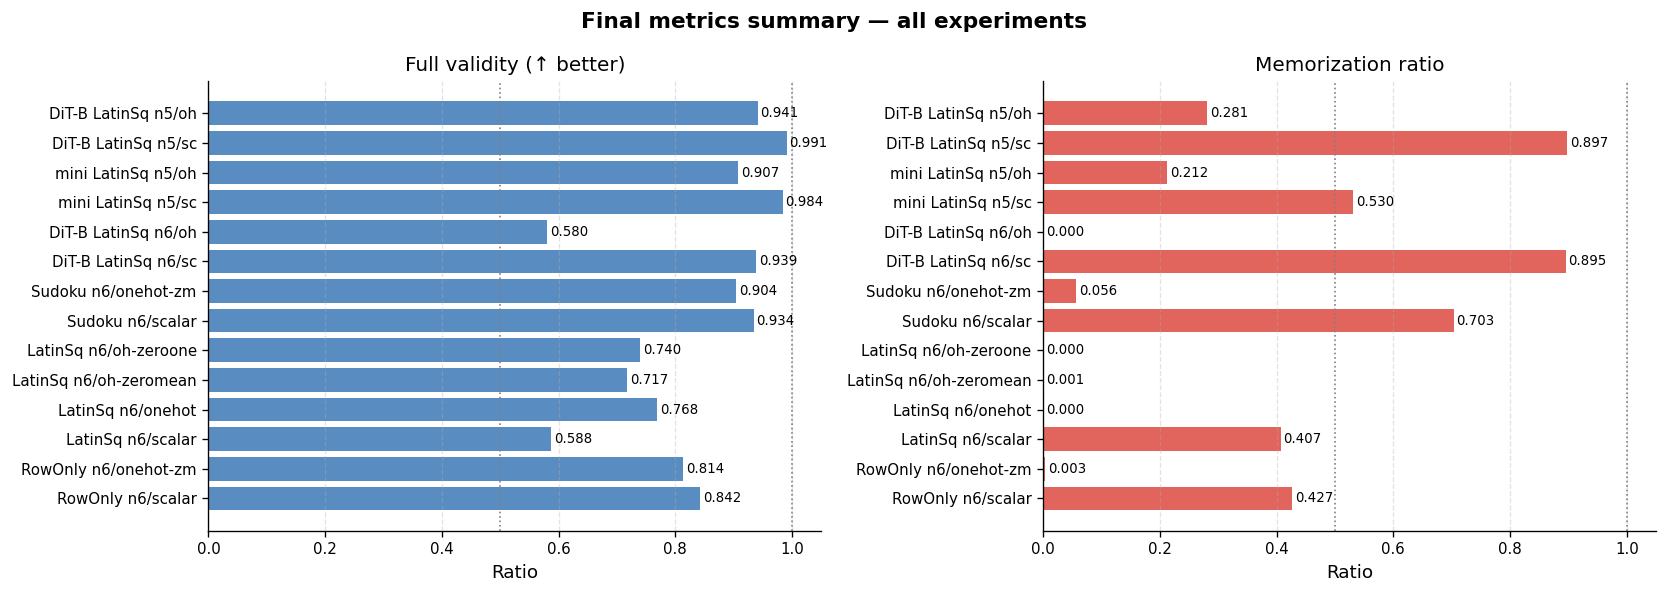

In [12]:
summary_keys = [
    ('RowOnly n6/scalar',      'RowOnly/scalar'),
    ('RowOnly n6/onehot-zm',   'RowOnly/onehot'),
    ('LatinSq n6/scalar',      'LatinSq/scalar'),
    ('LatinSq n6/onehot',      'LatinSq/oh-plain'),
    ('LatinSq n6/oh-zeromean', 'LatinSq/oh-zeromean'),
    ('LatinSq n6/oh-zeroone',  'LatinSq/oh-zeroone'),
    ('Sudoku n6/scalar',       'Sudoku/scalar'),
    ('Sudoku n6/onehot-zm',    'Sudoku/onehot'),
    ('DiT-B LatinSq n6/sc',    'B/LatinSq-scalar'),
    ('DiT-B LatinSq n6/oh',    'B/LatinSq-onehot'),
    ('mini LatinSq n5/sc',     'mini/n5-scalar'),
    ('mini LatinSq n5/oh',     'mini/n5-onehot'),
    ('DiT-B LatinSq n5/sc',    'B/n5-scalar'),
    ('DiT-B LatinSq n5/oh',    'B/n5-onehot'),
]

labels  = [s[0] for s in summary_keys]
fv_vals = [final_mean(s[1], 'eval/full_valid_ratio') for s in summary_keys]
mm_vals = [final_mean(s[1], 'eval/sample_mem_ratio')  for s in summary_keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Final metrics summary — all experiments", fontsize=13, fontweight='bold')

x = np.arange(len(labels))
for ax, vals, title, clr in [
    (axes[0], fv_vals, 'Full validity (↑ better)',  '#2166ac'),
    (axes[1], mm_vals, 'Memorization ratio',         '#d73027'),
]:
    bars = ax.barh(x, vals, color=clr, alpha=0.75)
    ax.set_yticks(x); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Ratio')
    ax.set_title(title)
    ax.axvline(0.5, color='gray', ls=':', lw=1)
    ax.axvline(1.0, color='gray', ls=':', lw=1)
    ax.grid(axis='x', ls='--', alpha=0.35)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
savefig(fig, 'summary_all_experiments.png')
plt.show()
